## Feature Engineering for Multiple Regression

This notebook is the code companion to the feature-engineering lecture notes. We use one
dataset throughout, the classic medical insurance `charges` data.

**What this notebook covers**

1. **Transformations** for linearity and variance - log, polynomial, Box-Cox, and how to tell which side of the model needs the transform.
2. **Categorical predictors** - dummy coding, and what changes when you pick a different reference level.
3. **Interactions** - does the effect of one predictor depend on another? We'll find a real dramatic one in this data.
4. **Centering and standardizing** - fixing interpretability and cutting down mechanical collinearity.

There's a companion interactive app for dummy variables and interactions, and another for regression diagnostics with adjustable severity, both on the [course site](https://robertclements.org/dsai601-regression-f26/), which is worth pulling up alongside this notebook.

In [51]:
%matplotlib inline
import matplotlib.pyplot as plt      # plotting
import pandas as pd                  # data frames
import numpy as np                   # arrays, np.log, np.maximum
import statsmodels.api as sm         # sm.stats.anova_lm -> nested-model F-tests
import statsmodels.formula.api as smf  # smf.ols -> fit a model from an R-style formula
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as spstats   # spstats.boxcox


### Load the data

Each row is one insurance policyholder: `age`, `sex`, `bmi`, `children` (count), `smoker`
(yes/no), `region` (four US regions), and `charges`. `charges` is the annual medical cost we want to
model as our response variable. `sex`, `smoker`, and `region` are text columns; pandas will read them as `object`
dtype, which is exactly what we want for the dummy-coding section.

In [52]:
insurance = pd.read_csv('../data/insurance.csv')
insurance.sample(5)

,age,sex,bmi,children,smoker,region,charges
110,54,male,33.630,1,no,northwest,10825.25370
417,36,female,22.600,2,yes,southwest,18608.26200
191,36,female,26.200,0,no,southwest,4883.86600
1304,42,male,24.605,2,yes,northeast,21259.37795
1075,32,female,29.590,1,no,southeast,4562.84210


In [53]:
insurance.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## 1. Transformations for linearity and variance

`charges` is a cost, which is strictly positive, and right-skewed. That combination is a strong hint that a log transform will help before we've fit anything.

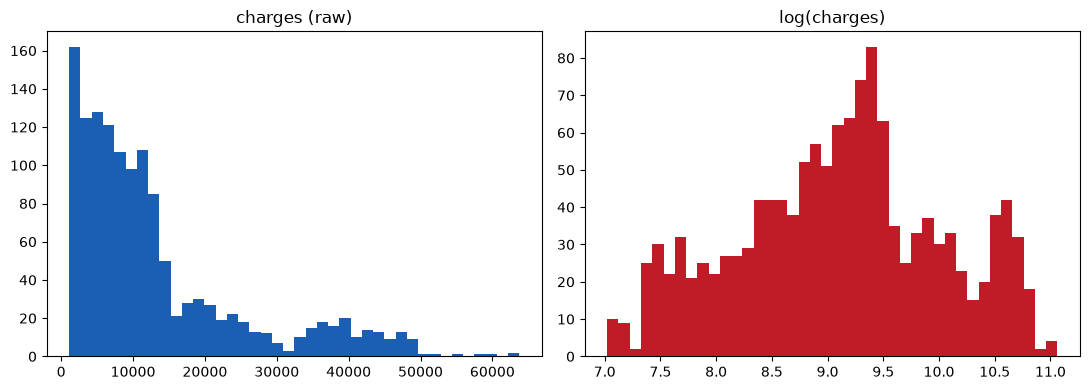

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(insurance['charges'], bins=40, color='#1a5fb4')
axes[0].set_title('charges (raw)')
axes[1].hist(np.log(insurance['charges']), bins=40, color='#c01c28')
axes[1].set_title('log(charges)')
plt.tight_layout()

Raw `charges` are clustered near zero with a long right tail. `log(charges)` looks far closer to Normal, which might be what we want.

Let's fit both and compare the residual plots.

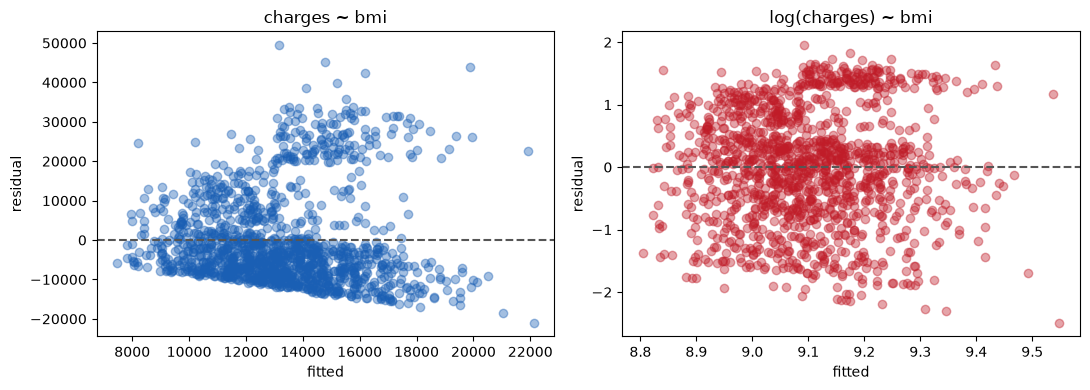

In [55]:
model_raw = smf.ols('charges ~ bmi', data=insurance).fit()
model_log = smf.ols('np.log(charges) ~ bmi', data=insurance).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(model_raw.fittedvalues, model_raw.resid, alpha=0.4, color='#1a5fb4')
axes[0].axhline(0, color='#555', linestyle='--')
axes[0].set_xlabel('fitted'); axes[0].set_ylabel('residual'); axes[0].set_title('charges ~ bmi')

axes[1].scatter(model_log.fittedvalues, model_log.resid, alpha=0.4, color='#c01c28')
axes[1].axhline(0, color='#555', linestyle='--')
axes[1].set_xlabel('fitted'); axes[1].set_ylabel('residual'); axes[1].set_title('log(charges) ~ bmi')
plt.tight_layout()

The funnel/fan shape is visibly worse in the raw-`charges` model and the non-constant variance signals to us that we may want to try transforming $Y$. The only thing we have to be careful of is the interpretation of the fitted model. Note that you can exponentiate the fitted values to return $Y$ to the original scale, but **these exponentiated fitted values are not the mean response**, they will be biased.

### Polynomial terms

`bmi`'s relationship with `charges` isn't very linear. It doesn't necessarily look quadratic either, but let's demonstrate a polynomial term by adding `I(bmi**2)` inside the formula adds a squared term without leaving `smf.ols`'s formula interface. The `I()` means to interpret what is inside the parentheses as-is.


Text(0.5, 1.0, 'charges ~ bmi')

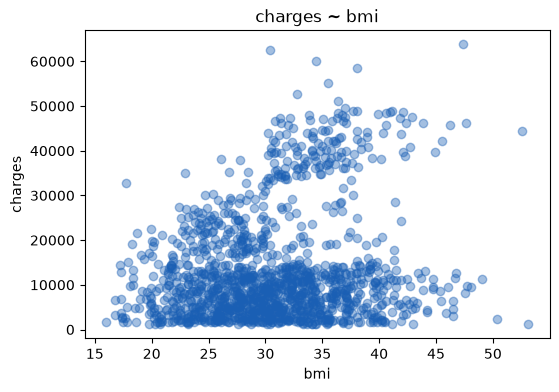

In [56]:
# Plot of charges vs. bmi
plt.figure(figsize=(6, 4))
plt.scatter(insurance['bmi'], insurance['charges'], alpha=0.4, color='#1a5fb4')
plt.xlabel('bmi'); plt.ylabel('charges'); plt.title('charges ~ bmi')

In [76]:
model_poly = smf.ols('charges ~ bmi + I(bmi**2)', data=insurance).fit()
model_poly.params

Intercept     -5177.034126
bmi             813.974958
I(bmi ** 2)      -6.662323
dtype: float64

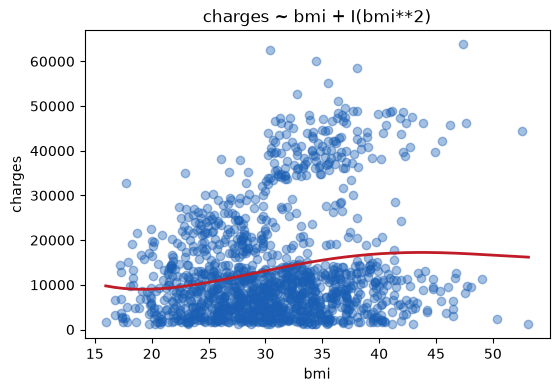

In [75]:
# Plot of charges vs. bmi with fitted regression line
plt.figure(figsize=(6, 4))
plt.scatter(insurance['bmi'], insurance['charges'], alpha=0.4, color='#1a5fb4')
plt.xlabel('bmi'); plt.ylabel('charges'); plt.title('charges ~ bmi + I(bmi**2)')
plt.plot(np.sort(insurance['bmi']), model_poly.fittedvalues[np.argsort(insurance['bmi'])], color='#c01c28', linewidth=2)

Reminder from the notes: with the squared term in the model, neither coefficient alone is the slope. The marginal effect of `bmi` is $\hat\beta_1 + 2\hat\beta_2 \cdot \text{bmi}$, which changes depending on where you evaluate it.

Just for fun, add `I(bmi**3)` and rerun the code to see the fitted line.

### Box-Cox: choosing a transform instead of guessing

Without getting into the weeds of it, `scipy.stats.boxcox` estimates $\hat\lambda$ by maximizing the profile log-likelihood (don't worry about the details of this) to find the best transform for $Y$.

In [61]:
boxcox_charges, fitted_lambda = spstats.boxcox(insurance['charges'])
print(f'Estimated lambda: {fitted_lambda:.3f}')

Estimated lambda: 0.044


$\hat\lambda$ comes out well close to 0, which means that Box-Cox is independently recommending something close to the log transform we already picked by eye. Feel free to read up more on these types of transformations.

Let's try it on one of the predictors. How about bmi or age?

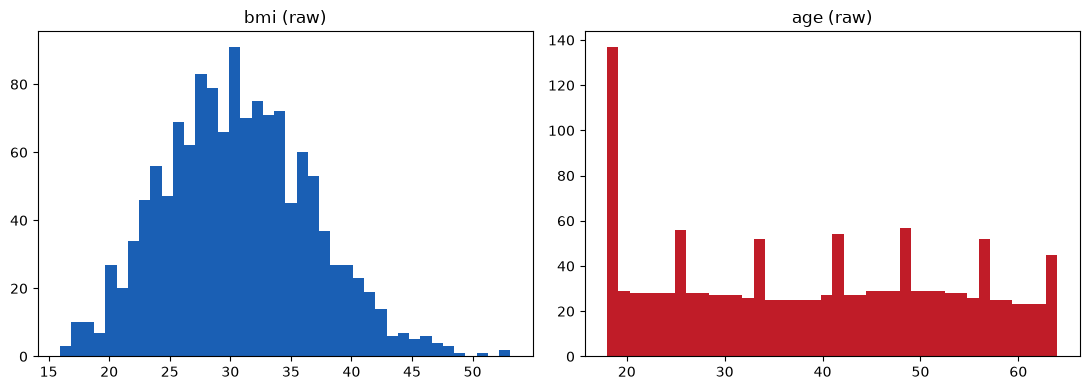

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(insurance['bmi'], bins=40, color='#1a5fb4')
axes[0].set_title('bmi (raw)')
axes[1].hist(insurance['age'], bins=40, color='#c01c28')
axes[1].set_title('age (raw)')
plt.tight_layout()

BMI looks good already, but age looks really strange. Let's see what Box-Cox chooses for this one.

In [63]:
boxcox_age, fitted_lambda = spstats.boxcox(insurance['age'])
print(f'Estimated lambda: {fitted_lambda:.3f}')

Estimated lambda: 0.623


Ok, now let's see transformed age.

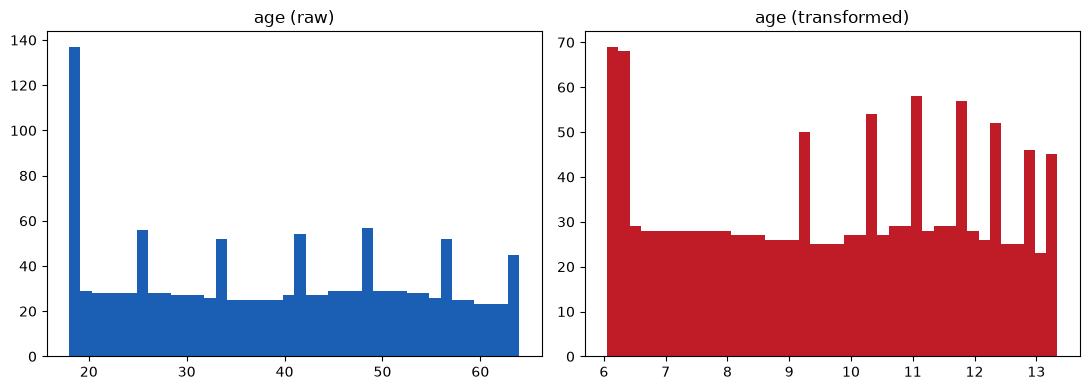

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(insurance['age'], bins=40, color='#1a5fb4')
axes[0].set_title('age (raw)')
axes[1].hist(insurance['age']**.623, bins=40, color='#c01c28')
axes[1].set_title('age (transformed)')
plt.tight_layout()

Ok, it didn't work. Box-Cox doesn't always work. It's possible a simple transformation isn't possible.

## 2. Categorical predictors

`smoker` is a two-level categorical variable. Wrapping it in `C()` inside a formula tells
statsmodels to dummy-code it. Note that the `C()` isn't strictly necessary.

In [65]:
model_smoker = smf.ols('charges ~ C(smoker)', data=insurance).fit()
model_smoker.params

Intercept            8434.268298
C(smoker)[T.yes]    23615.963534
dtype: float64

Two numbers, two meanings:

- **Intercept** = mean `charges` for the *reference* group of `smoker`. The reference group is chosen
  alphabetically by default, so here it's `smoker == 'no'`.
- **`C(smoker)[T.yes]`** = the *difference* in mean `charges` between smokers and
  non-smokers.

Let's check that against the raw group means directly.

In [66]:
insurance.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

$32{,}050.23 - 8{,}434.27 = 23{,}615.96$, which is exactly `C(smoker)[T.yes]` from
`model_smoker.params` above. The intercept is the non-smoker mean; the dummy coefficient is
the gap between the two group means, not the smoker mean by itself, because when `smoker=='yes'` we add the intercept and the coefficient together to get the mean for `smoker=='yes'`.

In [67]:
# Look at the design matrix for the smoker model
print(model_smoker.model.exog[10:20] )

# original data frame
insurance.iloc[10:20]


[[1. 0.]
 [1. 1.]
 [1. 0.]
 [1. 0.]
 [1. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 1.]]


,age,sex,bmi,children,smoker,region,charges
10,25,male,26.220,0,no,northeast,2721.32080
11,62,female,26.290,0,yes,southeast,27808.72510
12,23,male,34.400,0,no,southwest,1826.84300
13,56,female,39.820,0,no,southeast,11090.71780
14,27,male,42.130,0,yes,southeast,39611.75770
15,19,male,24.600,1,no,southwest,1837.23700
16,52,female,30.780,1,no,northeast,10797.33620
17,23,male,23.845,0,no,northeast,2395.17155
18,56,male,40.300,0,no,southwest,10602.38500
19,30,male,35.300,0,yes,southwest,36837.46700


### Changing the reference level

Now force the reference level to `'yes'` instead of the default `'no'`, using `Treatment()` coding.

In [ ]:
model_smoker_flip = smf.ols(
    "charges ~ C(smoker, Treatment(reference='yes'))", data=insurance
).fit()
model_smoker_flip.params

In [ ]:
print('Same fitted values regardless of reference level:',
      np.allclose(model_smoker.fittedvalues, model_smoker_flip.fittedvalues))

Every coefficient changed sign and the intercept jumped by tens of thousands of
dollars, but every *prediction* the model makes is identical. The reference level changes how you read
the coefficients, but doesn't change predictions.

### A categorical variable with more than two levels

`region` has four levels, so it gets $4-1=3$ dummy columns.

In [ ]:
model_region = smf.ols('charges ~ C(region)', data=insurance).fit()
model_region.params

Same reading rule as before: the intercept is the reference region's mean, and every other coefficient is a difference *from that reference*, not an absolute mean, since for every non-reference region we add the intercept to its coefficient.

In [ ]:
# Look at the design matrix for the region model
print(model_region.model.exog[10:20])

# original data frame
insurance.iloc[10:20]

## 3. Interactions

Motivating question: **does the effect of `bmi` on `charges` depend on whether someone
smokes?** Plot `bmi` against `charges`, colored by `smoker`, before fitting anything.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for smoker_status, color, marker in [('no', '#1a5fb4', 'o'), ('yes', '#a85d00', '^')]:
    subset = insurance[insurance['smoker'] == smoker_status]
    ax.scatter(subset['bmi'], subset['charges'], alpha=0.5, color=color, marker=marker,
               label=f'smoker = {smoker_status}')
ax.set_xlabel('bmi'); ax.set_ylabel('charges'); ax.legend()
plt.tight_layout()

It appears obvious that among non-smokers, `charges` barely moves with `bmi`; among smokers, it climbs sharply. One slope
will not describe both groups. Let's fit both the no-interaction and the interaction model and
overlay the fitted lines on the same picture. To include an interaction, we use `:`. Note that we include both predictors as *main effects* along with the interaction.

In [ ]:
model_no_int = smf.ols('charges ~ bmi + C(smoker)', data=insurance).fit()
model_int = smf.ols('charges ~ bmi + C(smoker) + bmi:C(smoker)', data=insurance).fit()

bmi_grid = np.linspace(insurance['bmi'].min(), insurance['bmi'].max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, model, title in [(axes[0], model_no_int, 'No interaction (forced parallel)'),
                          (axes[1], model_int, 'With interaction (separate slopes)')]:
    for smoker_status, color, marker in [('no', '#1a5fb4', 'o'), ('yes', '#a85d00', '^')]:
        subset = insurance[insurance['smoker'] == smoker_status]
        ax.scatter(subset['bmi'], subset['charges'], alpha=0.3, color=color, marker=marker)
        pred = model.predict(pd.DataFrame({'bmi': bmi_grid, 'smoker': smoker_status}))
        ax.plot(bmi_grid, pred, color=color, linewidth=2.5)
    ax.set_xlabel('bmi'); ax.set_title(title)
axes[0].set_ylabel('charges')
plt.tight_layout()

Same shape of story as the *Dummy Variables & Interactions* app, now on real data: the
no-interaction model is forced to draw two parallel lines and visibly undershoots the smoker
group's steep climb, while the interaction model bends to fit both groups.

Is the interaction actually needed, or could that gap be explained by noise? `anova_lm` runs
the nested-model (partial) F-test comparing the two models directly.

In [ ]:
# Compare the two models using an ANOVA F-test
# First argument is the reduced model, second argument is the full model
sm.stats.anova_lm(model_no_int, model_int)

The F-statistic here is large and the p-value is very small. Note the `bmi:C(smoker)` term has 1 degree of freedom: one interaction coefficient, exactly as in the two-group case from the lecture notes.

## 4. Centering and standardizing

`center()` and `standardize()` are built-in formula functions, which will either center the data by subtracting the mean, or standardize by subtracting the mean and dividing by the standard deviation.

In [ ]:
model_int_centered = smf.ols(
    'charges ~ center(bmi) + C(smoker) + center(bmi):C(smoker)', data=insurance
).fit()
model_int_centered.params

In [ ]:
model_int.params

Compare `Intercept` here to `Intercept` in `model_int` above. Centering `bmi` moved the intercept to mean the predicted charges at the *average* bmi for the reference smoking group, which is more meaningful that the previous intercept. You can see this by setting `smoker='yes'=0`, and `bmi='mean of bmi'=0`. The slope and interaction coefficients themselves are unchanged, because centering only shifts where the intercept is measured from.

### Standardized coefficients: comparing predictors on different scales

`age` is measured in years, `bmi` in kg/m², so their raw coefficients aren't comparable. `standardize()` z-scores each predictor first, so both coefficients end up in units of one standard deviation.

In [ ]:
model_std = smf.ols('charges ~ standardize(age) + standardize(bmi) + C(smoker)',
                     data=insurance).fit()
model_std.params

Now the `age` and `bmi` coefficients are directly comparable in size, and whichever one
is larger in absolute value moves `charges` more per one standard deviation change in that predictor, holding
the others fixed. That comparison would not have been meaningful with the raw, differently-
scaled coefficients. But note, this way of interpreting the coefficients is actually not that common.

## 5. Cautions

Three quick, self-contained illustrations.

### Ratio variables can manufacture correlation

Construct two variables that are pure noise, unrelated to each other -- then divide both by
the same shared quantity and watch a correlation appear.

In [ ]:
rng = np.random.default_rng(0)
n = 500
count_a = rng.normal(100, 20, n)             # independent of count_b
count_b = rng.normal(100, 20, n)             # independent of count_a
shared_denominator = rng.uniform(50, 500, n)  # e.g. "population" -- independent of both

ratio_a = count_a / shared_denominator
ratio_b = count_b / shared_denominator

print('corr(raw counts a, b):     ', np.corrcoef(count_a, count_b)[0, 1].round(3))
print('corr(the two ratios):     ', np.corrcoef(ratio_a, ratio_b)[0, 1].round(3))

`count_a` and `count_b` are independent by construction. But `ratio_a = count_a / shared_denominator` and `ratio_b = count_b /
shared_denominator` come out strongly correlated, purely because they share the same random
denominator. Nothing links `count_a` and `count_b` themselves; the correlation is entirely
manufactured by dividing both by the same third variable.

### Leakage

A feature that's an algebraic function of `y` will look unbeatable and mean nothing. Leakage is a common problem that you must be very careful not to accidentally include in a model.

In [ ]:
leaky_feature = (insurance['charges'] / 100).round() * 100   # "charges rounded to the nearest $100"
leak_check = smf.ols('charges ~ leaky_feature', data=insurance).fit()
print(f'R-squared with a feature built from y itself: {leak_check.rsquared:.6f}')

An $R^2$ this close to 1 is a huge red flag.

## Exercises

**Exercise 1.** Look at the fitted `region` model from section 2
(`model_region`, the one with `C(region)` and no other predictors). Which region has the
*highest* predicted mean `charges`, and what is that region's coefficient?

In [ ]:
# your work here


**Exercise 2.** Using the two models already fit in section 3
(`model_no_int` and `model_int`), write one line of code to predict `charges` for a
**smoker** with `bmi = 45` under each model. Which model's prediction looks more
believable given the scatter plot earlier in that section -- and why?

In [71]:
# your work here
model_int.predict(pd.DataFrame({'bmi': 45, 'smoker': ['yes']}))
model_no_int.predict(pd.DataFrame({'bmi': 45, 'smoker': ['yes']}))

0    37595.571544
dtype: float64

**Exercise 3.** In the ratio-variables demonstration from section 5, what was the
correlation between the two raw counts (`count_a`, `count_b`)? What was it between the
two ratios built from them? In one sentence, explain where that gap comes from.

In [ ]:
# your work here
